# Estimating the Nelson and Siegel Model


<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Volume-Three-Chapter-Three/blob/master/colab/Colab_bond_payment_data.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>

  <a href="https://mybinder.org/v2/gh/PatrickJHess/Volume-Three-Chapter-Three/master?urlpath=lab/tree/notebooks/Bootstrappinmg Zero Prices.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>

  <a href="https://patrickjhess.github.io/Volume-Three-Chapter-Three/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>
</div>

## Estimating the Parameters: A Non-Linear Least Squares Approach

With the Nelson-Siegel framework established, the next step is to estimate the four parameters ($\beta_0, \beta_1, \beta_2$, and $\tau$) using our dataset of 399 bonds. Unlike the ordinary least squares (OLS) approach used in Chapter Three, the Nelson-Siegel parameters enter the yield curve equation non-linearly. Therefore, we must use a non-linear least squares optimization to find the parameters that best fit the observed market data. The process relies on minimizing the distance between the actual observed market prices of the bonds and the theoretical prices forecasted by the model.

### Step 1: Forecasting bond prices
First, we use the Nelson-Siegel spot rate, $r(t)$, to determine the zero price, $zero(t)$, for any future payment date:

$$zero(t) = e^{-r(t) \times t}$$

For any given bond $i$ in our dataset, the forecasted theoretical price ($\hat{P}_i$) is simply the sum of all its future cash flows ($Cash\ Flow_{i,t}$) multiplied by the zero price corresponding to each payment date:

$$\hat{P}_i = \sum_{t} Cash\ Flow_{i,t} \times e^{-r(t) \times t}$$

### Step 2: Minimizing the pricing error
Once the theoretical prices are forecasted, we compare them to the actual, observed market prices ($P_i$). The goal of the optimization is to find the specific combination of $\beta_0, \beta_1, \beta_2$, and $\tau$ that minimizes the sum of squared residuals (SSR) across all 399 bonds:

$$\text{SSR} = \sum_{i=1}^{399} (P_i - \hat{P}_i)^2$$

### Step 3: The Optimization Routine using SciPy

To execute this minimization, we utilized the optimize module within Python's SciPy library. Because our objective function is highly non-linear, the optimization algorithm requires a set of initial parameter guesses to begin its search.Choosing reasonable starting values is critical to ensure the algorithm converges on the true global minimum rather than getting trapped in a local minimum. For our initial state, we approximate the parameters based on their economic interpretations:

* $\beta_0$ (Level): Initialized near the yield of the longest-maturity bond in the dataset.

* $\beta_1$ (Slope): Initialized as the difference between the shortest-maturity yield and the longest-maturity yield.

* $\beta_2$ (Shape): Initialized at $0$, assuming a flat curvature to start.

* $\tau$ (Scale): Initialized at a standard medium-term value, such as $1$ or $3$.

From these starting values, SciPy's non-linear least squares solver iteratively adjusts the four parameters. At each step, it evaluates the squared distance between the actual and forecasted prices until it converges. This final set of optimized parameters defines the Nelson-Siegel yield curve that best represents the term structure hidden in our bond dataset.

## Preparing the notebook

SciPy stands for scientific Python and is a powerul library built opne NumPy,  In this notebok, the function `minimze` of `scipy.optimize` (a subset of SciPy) is used to find the estimates of $\beta_0,\beta_1,\ \beta_2,\text{ and }\tau$.  

<details style="border: 1px solid #b8daff; border-radius: 8px; padding: 15px; background-color: #f8fbff; margin: 20px 0;">
  <summary style="cursor: pointer; font-weight: bold; font-size: 1.1em; color: #004085; font-family: sans-serif; list-style-position: inside;">
    <span style="margin-right: 8px;">🛠️</span> Notebook Setup: Why the "Try/Except" Imports?
  </summary>
  <div style="margin-top: 15px; padding-top: 15px; border-top: 1px solid #b8daff; color: #333333; font-family: sans-serif; font-size: 0.95em;">
    <b>The Goal:</b><br>
    To ensure this notebook runs perfectly whether you are using <b>Google Colab</b>, a local <b>Jupyter instance</b>, or a remote server without you having to manually install software.<br><br>
    <b>Key Concepts in this Section:</b>
    <ul style="line-height: 1.6; margin-bottom: 0;">
      <li><b>Standard Libraries:</b> Modules like <code>os</code>, <code>sys</code>, and <code>datetime</code> come "in the box" with Python. We use them for system tasks and date math.</li>
      <li><b>External Libraries:</b> NumPy and Pandas are the "heavy hitters" for data. They aren't always installed by default.</li>
      <li><b>The <code>try/except</code> Logic:</b> This is a safety net.
        <ol style="margin-top: 4px; margin-bottom: 4px; padding-left: 20px;">
          <li>We <b>try</b> to import the library.</li>
          <li>If it fails (because it's not installed), the <b>except</b> block triggers a <code>!pip install</code> to download it automatically.</li>
        </ol>
      </li>
      <li><b>Aliasing (<code>as np</code>):</b> We rename <code>numpy</code> to <code>np</code> to save keystrokes. In professional finance code, <code>np</code> and <code>pd</code> are the universal shorthand.</li>
    </ul>
  </div>
</details>

### Importing libraries, modules, And functions

Modules that are included in the standard Python library are imported. When necessary, other modules or libraries are installed before they are imported.  (see [Control Statements](https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/Control_Statements.html#the-try-and-except)).

```
import os
import sys
import requests
from datetime import datetime, date
from types import ModuleType

try:
    import numpy as np
except:
    !pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip -q install pandas
    import pandas as pd

try:
    from scipy.optimize import minimize
except:
    !pip -q install scipy
    from scipy.optimize import minimize
```

In [2]:
import os
import sys
import requests
from datetime import datetime, date
from types import ModuleType

try:
    import numpy as np
except:
    !pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip -q install pandas
    import pandas as pd

try:
    from scipy.optimize import minimize
except:
    !pip -q install scipy
    from scipy.optimize import minimize

<details>
<summary><b style="font-size:1.2em; color: #1976d2; cursor: pointer;">👍 Important: Cloud-Loading: How In-Memory Modules Work</b></summary>
<br>
<p><b>The Logic:</b><br>
Usually, Python looks for modules as <code>.py</code> files on your hard drive. Here, we are "tricking" Python into treating a string of text from a URL as a live library.</p>

<p><b>The Workflow:</b></p>
<ol>
<li><b>Fetch:</b> <code>requests.get(url)</code> grabs the raw text of your Python script from Dropbox.</li>
<li><b>Instantiate:</b> <code>ModuleType(module_name)</code> creates an empty "container" in your computer's RAM.</li>
<li><b>Execute:</b> <code>exec(code, module.__dict__)</code> runs that text inside the container, turning text into live functions.</li>
<li><b>Register:</b> By adding it to <code>sys.modules</code>, we tell Python: <em>"If I try to import this later, don't look on the disk—look right here in the memory."</em></li>
</ol>

<p><b>Why do this?</b><br>
It makes your notebooks <b>100% portable</b>. A user can open this in a brand-new environment, and as long as they have an internet connection, all your custom financial functions will "just work."</p>
</details>

In [33]:
# Define the URL of the Python module to be downloaded from Dropbox.
# The 'dl=1' parameter in the URL forces a direct download of the file content.
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=87sztshr&dl=1'
module_name='basic_concepts_fixed_income'
# Send an HTTP GET request to the URL and store the server's response.
try:
    response = requests.get(url)
    module = ModuleType(module_name)
    exec(response.text, module.__dict__)
    sys.modules[module_name] = module
    # Now we can import from our in-memory module
    from basic_concepts_fixed_income import (FEDInvest,
                                             clean_FEDInvest,
                                             accrued_interest,
                                             create_payoff_df,
                                             ns_spot_rates,
                                             estimate_ns_parameters,
                                              one_y_axis)
    print(f"✅ Successfully imported module from URL.")

except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")
    # Now we can import from our in-memory module

✅ Successfully imported module from URL.


## Constructing the Payoff Matrix

Just like in Chapter Three, the April 27, 2026 data is downloaded (df) and converted into a clean DataFrame (clean_df).

### Getting the data from FEDInvest

In [34]:
my_date=datetime(2026, 4,27)

# Fetch Treasury data for a specific date
df, stamp,settlement = FEDInvest(my_date)

#Display price and date and settlement
display(f'Date of prices {stamp}  Settlement date  {settlement}')

# Display the first few rows
display(df.head())

'Date of prices 2026-04-27  Settlement date  2026-04-28'

,CUSIP,SECURITY TYPE,RATE,MATURITY DATE,CALL DATE,BUY,SELL,END OF DAY
1,912797SN8,MARKET BASED BILL,0.000%,2026-04-30,NaN,0.000000,99.970000,99.980111
2,912797TL1,MARKET BASED BILL,0.000%,2026-05-05,NaN,99.920333,99.920000,99.930389
3,912797SP3,MARKET BASED BILL,0.000%,2026-05-07,NaN,99.900556,99.900278,99.910000
4,912797TR8,MARKET BASED BILL,0.000%,2026-05-12,NaN,99.850417,99.850000,99.860000
5,912797QN0,MARKET BASED BILL,0.000%,2026-05-14,NaN,99.830708,99.830472,99.840444


### Standardizing the data

In [5]:
clean_df=clean_FEDInvest(df)
display(clean_df.head())

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY
MATURITY DATE,,,,,
2026-04-30,MARKET BASED BILL,0.000,0.000000,99.97000,99.980111
2026-04-30,MARKET BASED NOTE,4.875,0.000000,100.00000,100.000000
2026-04-30,MARKET BASED NOTE,0.750,0.000000,99.96875,99.968750
2026-04-30,MARKET BASED NOTE,2.375,0.000000,99.96875,100.000000
2026-05-05,MARKET BASED BILL,0.000,99.920333,99.92000,99.930389


### Defining the payoff matrix

Unlike in Chapter Three, where the payoff DataFrame was constructed for OLS and strictly required a full-rank matrix, our current method is more flexible. Here, the payoff matrix is simply multiplied by tentative zero prices during each iteration (*Step 1.: Forecasting bond prices*). Because this process does not require the matrix to be full rank, we set the `create_payoff_matrix` function's `OLS `parameter to False and include the complete set of 399 bonds in the DataFrame.

In [6]:
# the completon index assumes all the bonds are processed
df_payoff_matrix=create_payoff_df(clean_df,settlement,OLS=False)

# full rank rquired to infer zero prices
# linalg module to confirm full rank
rank=np.linalg.matrix_rank(df_payoff_matrix)
num_columns=df_payoff_matrix.shape[1]

# show rank and shape of DataFrame
if rank<num_columns:
 text='Payoff matrix is not full rank'
else:
 text='Payoff matrix is full rank'
display(f'{text}, Ranks is {rank}, Shape is {df_payoff_matrix.shape} ')

'Payoff matrix is not full rank, Ranks is 268, Shape is (399, 273) '

## Calculate the bond prices (dirty= clean + accrued interest)

We first calculate the actual transaction prices for all 399 bonds. During each iteration, the Sum of Squared Residuals (SSR) measures the deviation between the actual prices and those forecasted by the model.

In [7]:
# create the DataFrame from the bonds included in the payoff_matrix
# copy used to make sure the DataFrames aren't linked
num_rows=df_payoff_matrix.shape[0]
df_data=clean_df[:num_rows].copy()

# vectorized cakculation of clean prices
# the boolean value of bid and ask prices
bid_ask_true=(df_data['Price Bid']>0) & (df_data['Price Ask']>0)

# bid/ask average assigned to true_value
true_value=(df_data['Price Bid']+df_data['Price Ask'])/2

# maximum of three prices assigned to false value
false_value=df_data[['END OF DAY','Price Bid','Price Ask']].max(axis=1)

# equivalent to a vectorized if-else assignment of cleab oruce
df_data['Clean Price']=np.where(bid_ask_true,true_value,false_value)

# calculate accrued interest with apply method
# Settlement date returned by FEDInvest
df_data['Accrued Interest'] = df_data.apply(
    lambda row: accrued_interest(
        maturity=row.name,        # Value of index is the maturity date
        coupon=row['Coupon'],
        settlement=settlement
    ),
    axis=1                        # Explicitly state axis=1 row-by-row
)

# Vectorize the dirty price calculation

df_data['Dirty Price'] = df_data['Clean Price'] + df_data['Accrued Interest']

display(df_data.head())

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY,Clean Price,Accrued Interest,Dirty Price
MATURITY DATE,,,,,,,,
2026-04-30,MARKET BASED BILL,0.000,0.000000,99.97000,99.980111,99.980111,0.000000,99.980111
2026-04-30,MARKET BASED NOTE,4.875,0.000000,100.00000,100.000000,100.000000,2.410566,102.410566
2026-04-30,MARKET BASED NOTE,0.750,0.000000,99.96875,99.968750,99.968750,0.370856,100.339606
2026-04-30,MARKET BASED NOTE,2.375,0.000000,99.96875,100.000000,100.000000,1.174378,101.174378
2026-05-05,MARKET BASED BILL,0.000,99.920333,99.92000,99.930389,99.920166,0.000000,99.920166


## Extracting the index and  Dirty Prices
Alhough NumPy seamlessly treats Pandas DataFrames and Indexes as "array-like" objects for basic math, strict optimization functions require pure arrays.

First, we calculate the time to maturity by converting the column dates of the payoff DataFrame into a Pandas Index representing the years since the settlement date. This is assigned to the variable `mat_years`. Finally, we isolate the Dirty Price column from the data and assign it to `P_actual` (we will strip its Pandas index later during the SSR calculation).

In [8]:
mat_years=(pd.to_datetime(df_payoff_matrix.columns)-pd.to_datetime(settlement)).days/365.25
P_actual=df_data['Dirty Price']

## Calculating rates used for forecasted prices

The function `ns_spot_rates` is passed values for $\beta_0,\beta_1,\ \beta_2,\text{ and }\tau$ that are used to calculate spot rates for `mat_years`.  Those values are used for Step 1 by the `predict_prices` function. The `ns_spot_rates` function is imported from the `basic_concepts_fixed` module but the `predict_prices` function is included in the function used to estimate the model.

You can view function and a code snippet demonstrates it.

<details>

<summary style="cursor: pointer; font-size: 1.1em; color: #1a237e;"><b> 🔍 Click to see the <code>ns_spot_rates</code>function</b></summary>

```python
def ns_spot_rates(interim_estimates,mat_years):

  # current values of estimates
  b_0,b_1,b_2,tau=interim_estimates

  # t saves typing
  t=mat_years

  # Avoid division by zero for t=0
  t = np.where(t == 0, 1e-8, t)
  # Nelson-Siegel model
  spot_rates=b_0+b_1*(1-np.exp(-t/tau))/(t/tau)\
  +b_2*((1-np.exp(-t/tau))/(t/tau)-np.exp(-t/tau))

  # pass these rates to the objective function for step one
  return spot_rates,t
```
</details>

<details>

<summary style="cursor: pointer; font-size: 1.1em; color: #1a237e;"><b> ✂️ Code snippet to demonstrate the function.</b></summary>
 ✂️ Code snippet to see an example of the function.


```python
# make sure numpy is imported
import numpy as np

# values for demonstration
estimated_parameters=(0.056,-0.013,-0.034,2.6)
time_index=np.array([0.001,0.5,1.0,5.0,10.0,30.0])

# call the function
rates,maturities=ns_spot_rates(estimated_parameters,time_index)
display(rates)
display(maturities)
```
</detaails>

## Calculating predicted prices and the sum of squared pricing errors

The `predict_prices` function takes tenative estimates of $\beta_0,\beta_1,\ \beta_2,\text{ and }\tau$ (`interim_estmates`), the payoff DataFrame, the actual bond prices, and `mat_years` (maturity date in years of each column) and calculates forecasted prices with the rates returned by `ns_spot_rates` (Step 1).

It then calculates the sum of squared pricing errors (Step 2).

<details>

<summary style="cursor: pointer; font-size: 1.1em; color: #1a237e;"><b> 🔍 Click to see the <code>predict_prices</code>function</b></summary>

```python
def predict_prices(interim_estimates,df_payoff_matrix,P_actual,mat_years):

  # for step 1 get rates
  spot_rates,mat_years=ns_spot_rates(interim_estimates,mat_years)

  # calculate zero prices
  zero_prices=np.exp(-spot_rates*mat_years)

  # calculate predicted prices (@ here is the same as np.matmul)
  P_predicted=df_payoff_matrix@zero_prices

  # step 2 calculate the distance with sum of squared residuals
  ssr= np.sum((P_actual.values-P_predicted)**2)
  return ssr
```

</details>

## Estimating $\beta_0,\beta_1,\ \beta_2,\text{ and }\tau$ with SciPy `minimize`

The `minimize` function requires

* **The objective function**: The function calculating the sum of the squared residuals (`predict_prices`).

* **Initial guesses** (x0): The starting parameters being searched (`interim_estimates`).

* **Arguments (args)**: The extra data used by the objective function (`df_payoff_matrix`, `P_actual`, `mat_years`).

* **Method (optional)**: The Nelder-Mead method is a derivative-free method that is relatively slow but effectively accounts for noisy data.

## Results of estimates

The minimize function returns an object containing information about the success of the minimization procedure, as well as the final estimates for our coefficients. We will focus on the two most important attributes:

* `ns.result.x`: These are the final optimized estimates for $\beta_0, \beta_1, \beta_2,$ and $\tau$.

* `result.message`: A string detailing the status of the minimization procedure (e.g., whether it successfully converged or failed).

We won't examine the other attributes in this chapter, but you can always view everything inside the result object by running a quick line of code:


```
dir(ns_results)
```

<details>

<summary style="cursor: pointer; font-size: 1.1em; color: #1a237e;"><b> 🔍 Click to see the <code>estimate_ns_parameters</code>function</b></summary>


```python
def estimate_ns_parameters(df_payoff_matrix,P_actual,mat_years,guesses):

  # objective function is sum squared residuals (SSR)
  def predict_prices(interim_estimates,df_payoff_matrix,P_actual,mat_years):

    # for step one get rates
    spot_rates,mat_years=ns_spot_rates(interim_estimates,mat_years)

    # calculate zero prices
    zero_prices=np.exp(-spot_rates*mat_years)

    # calculate predicted prices (@ here is the same as np.matmul)
    P_predicted=df_payoff_matrix@zero_prices

    # step 2 calculate the distance with sum of squared residuals
    ssr= np.sum((P_actual.values-P_predicted)**2)
    return ssr

  # use the scipy minimize function to estimate parameters

  # Nelder-Mead doesn't take derivatives and tolerant of data
  method='Nelder-Mead'

  # minimize results
  ns_results=minimize(fun=predict_prices,
                  x0=guesses,
                  args=(df_payoff_matrix,P_actual,mat_years),
                  method=method)

  # get estimated coefficients of Nelson-Siegel
  b_0,b_1,b_2,tau=ns_results.x

  # get status of minimization
  completion_status=ns_results.message

  display(f'Completion status: {completion_status}')
  display(f'Long Rate (Beta Zero) {b_0:.4f}..Slope (Beta One) {b_1: .4f}...\
  Shape (Beta Three) {b_2: .4f}...Scaling (Tau) {tau: .4f}')
  return ns_results
```
</details>


## Estimation results



In [10]:
# intial guesses from Chapter Three
guesses=[0.045,-0.001,0.0,2]

# results include estiamted values and status of minimization problem
results=estimate_ns_parameters(df_payoff_matrix,P_actual,mat_years,guesses)


'Completion status: Optimization terminated successfully.'

'Long Rate (Beta Zero) 0.0564..Slope (Beta One) -0.0158...  Shape (Beta Three) -0.0339...Scaling (Tau)  2.5979'

## Spot and forward rates

### Spot rates

* Get the estimates of $\beta_0,\beta_1,\beta_2,\text{ and } \tau$ from the function
* Pass the estimated values and maturity in years to `ns_spot_rates`


### Forward rates

As established in Chapter One, the continuous forward interest rate between time $t$ and $t+\Delta t$ is defined as:

$$f(t,t+\Delta t) = \dfrac{\ln(\text{zero}(t)) - \ln(\text{zero}(t+\Delta t))}{\Delta t}$$
<br>

By substituting the zero-coupon pricing formula into this equation, we get:
<br><br>
$$f(t,t+\Delta t) = \dfrac{\ln(e^{\textstyle -\text{spot}(t)\times t}) - \ln(e^{\textstyle -\text{spot}(t+\Delta t) \times(t+\Delta t)})}{\Delta t}$$
<br>
Simplifying the natural logarithms and exponents yields the final forward rate formula:
<br><br>
$$f(t,t+\Delta t) = \dfrac{-\text{spot}(t)\times t + \text{spot}(t+\Delta t)\times (t+\Delta t)}{\Delta t}$$
<br><br>
This mathematical relationship is highly practical when applied programmatically. Because the `ns_spot_rates` function returns arrays for both spot rates and maturities, we can efficiently compute the forward rates using element-wise vector operations.

```
# Get spot rates and maturity in years from 'ns_spot_rates'.
# The 'x' attribute of the results contains the estimated coefficients.
spot_rates, maturity_years = ns_spot_rates(results.x, mat_years)

# Create the 'spot_maturity' array with element-wise multiplication
spot_maturity = spot_rates * maturity_years

# np.diff calculates the difference between adjacent elements (i+1 - i).
# We divide the differences in spot_maturity by the differences in maturity_years.
forward_rates = np.diff(spot_maturity) / np.diff(maturity_years)
```


## The analytical forward rate curve

Nelson and Siegel define the instantaneous forward rate $f(t)$ as:$$f(t) = \beta_0 + \beta_1 e^{-t/\tau} + \beta_2 \left(\frac{t}{\tau}\right) e^{-t/\tau}$$Because this function only yields instantaneous rates at a precise maturity $t$, determining forward rates over a discrete interval $\Delta t$ requires deriving zero-coupon prices or spot rates at discrete maturity dates.

In [11]:
# Get spot rates and maturity in years from 'ns_spot_rates'.
# The 'x' attribute of the results contains the estimated coefficients.
spot_rates, maturity_years = ns_spot_rates(results.x, mat_years)

# Create the 'spot_maturity' array with element-wise multiplication
spot_maturity = spot_rates * maturity_years

# np.diff calculates the difference between adjacent elements (i+1 - i).
# We divide the differences in spot_maturity by the differences in maturity_years.
forward_rates = np.diff(spot_maturity) / np.diff(maturity_years)

# insert nan as first element in forward rates so the arrays match up
forward_rates=np.insert(forward_rates,0,np.nan)

## Plotting spot and forward rates with `one_y_axis` function.

❓ Do you want to save the file? (y/n) (press enter for n):  n


### ***❌ File Not Saved***.

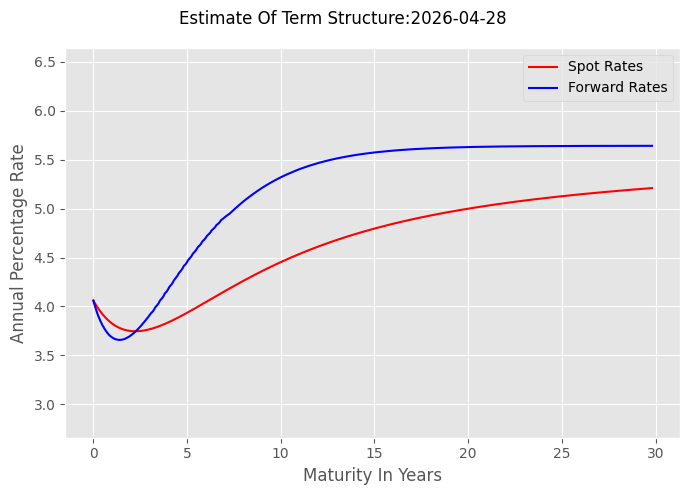

In [12]:
plot_data=[spot_rates*100,
           forward_rates*100]
#X axis time in years
xaxis=maturity_years
series=['Spot Rates',
        'Forward Rates']
ylabel='Annual Percentage Rate'
xlabel='Maturity In Years'
size=(7,5)
markers=['']*2
colors=['r','b']

# use nanmin and nanmax so that nan is ignogred
y_lower=np.nanmin(plot_data)-1
y_upper=np.nanmax(plot_data)+1


ylim=[y_lower,y_upper]
title='Estimate Of Term Structure:'+settlement.strftime('%Y-%m-%d ')
one_y_axis(xaxis,plot_data,title,series,xlabel,ylabel,markers,size,ylim,
           colors=colors)

## Summarizing the results

The term structure indicates that interest rates are expected to decline in the near term before steadily increasing, ultimately reaching 5.64% at the longest maturity. The 30-year spot rate is 5.21%, but the corresponding forward rate aligns with the estimate for $\beta_0$ at 5.64%. As maturity approaches infinity, the spot rate will converge with the forward rate.

As established in Chapter One, spot and forward rates provide profound insights into the current state of the capital markets. More importantly, they serve as a fundamental guide for pricing assets and formulating financial strategies. As we will explore in the next volume, understanding the term structure is critical for valuing financial instruments and shaping both investment and financing decisions.

<div style="padding: 15px; border: 1px solid #e0e0e0; border-left: 5px solid #ffc107; background-color: #fffde7; border-radius: 4px; margin-bottom: 15px;">
  <b> ✍️ Term Structure Challenges using FEDInvest Data.<br><br>
(Assume a settlement date of May 6, 2026)
</div>


**Challenge 1: Bond Pricing**
Using the provided FEDInvest term structure data, derive the Nelson-Siegel yield curve estimates. Apply these estimates to a U.S. Treasury bond maturing on June 30, 2045, with a 5.0% coupon rate. (Note: Assume standard U.S. Treasury conventions, including semiannual coupon payments and Actual/Actual day-count).

1. Calculate the forecasted dirty price of the bond.

2. Calculate the forecasted clean price of the bond.

<details>
<summary>🛟 <b>Need hints or a solution?</b></summary>

<br>

<details style="margin-left: 20px;">
<summary>💡 <b>Hints</b></summary>

* **Imports:** Refer to the Preparing notebook section of this notebook. In addtion you will need to import the `bond_pay_data` function of Chapter Three.
* **Get Data**
    *   FEDInvest
    *   spot rates
    *   Payment dates and amounts
    *   Zero prices from spot prices
    *   Accrued intrest
</details>

<br>

<details style="margin-left: 20px;">
<summary>✅ <b>Example Of Solution</b></summary>

```py
# set the maturity and settlement date
# assuming imports of this notebook add bond
from basic_concepts_fixed_income import bond_pay_data

# FEDInvest data
my_date=date(2026,5,5)

# get FEDInvest data and clean it up
# Fetch Treasury data for a specific date
df, stamp,settlement = FEDInvest(my_date)
clean_df=clean_FEDInvest(df)

# create payoff 
df_payoff_matrix=create_payoff_df(clean_df,settlement,OLS=False)
df_data=clean_df.copy()

# clean prices
bid_ask_true=(df_data['Price Bid']>0) & (df_data['Price Ask']>0)
true_value=(df_data['Price Bid']+df_data['Price Ask'])/2
false_value=df_data[['END OF DAY','Price Bid','Price Ask']].max(axis=1)
df_data['Clean Price']=np.where(bid_ask_true,true_value,false_value)

# accrued intret
df_data['Accrued Interest'] = df_data.apply(
    lambda row: accrued_interest(
        maturity=row.name,        # Value of index is the maturity date
        coupon=row['Coupon'],
        settlement=settlement
    ),
    axis=1                        # Explicitly state axis=1 row-by-row
)
# dirty prices
df_data['Dirty Price'] = df_data['Clean Price'] + df_data['Accrued Interest']
mat_years=(pd.to_datetime(df_payoff_matrix.columns)-pd.to_datetime(settlement)).days/365.25
P_actual=df_data['Dirty Price']

# estimate model
guesses=[0.045,-0.001,0.0,2]
results=estimate_ns_parameters(df_payoff_matrix,P_actual,mat_years,guesses)


# bond payment data and corresponding zero prices
maturity=datetime(2045,6,30)
coupon=5
dates,amounts=bond_pay_data(maturity,coupon,settlement)
mat_years=(pd.to_datetime(dates)-pd.to_datetime(settlement)).days/365.25
spot_rates,maturity_years=ns_spot_rates(results.x,mat_years)
zero_prices=np.exp(-spot_rates*maturity_years)

# calculate dirty price as sum of zero prices and bond payments
dirty_price=np.sum(amounts*zero_prices)

# calculate accrued interest and clean price
accrured=accrued_interest(maturity,coupon,settlement=settlement)
clean_price=dirty_price-accrured
display(f'Dirty Price: {dirty_price: .4f}...Clean Price: {clean_price: .4f}')  
```
</details>

<br>


**Challenge 2: Forward Rates and Swap Pricing**

A firm is entering a 5-year floating-rate debt agreement that begins on September 6, 2026. The interest rate will reset every six months at the prevailing 6-month Treasury rate plus a 2% spread.

1. Using your Nelson-Siegel term structure estimates, determine the fair discrete forward rate to lock in today for each of the ten 6-month periods.

2. Describe the methodology you would use to determine the equivalent fixed rate (swap rate) for this entire 5-year agreement. (You do not need to calculate the final fixed rate, just explain the steps and formulas conceptually).

<details>
<summary>🛟 <b>Need hints or a solution?</b></summary>

<br>

<details style="margin-left: 20px;">
<summary>💡 <b>Hints</b></summary>

* **Imports:** Refer to the Preparing notebook section of this notebook
* **Reset Dates**: Use pd.DateOffest to calculate dates for setting the rate (Chaper Two-`scheduled_pay_dates`)
* **Continuoius to Discrete Rates**: (Chapter One-Bond Pricing)
</details>

<br>

<details style="margin-left: 20px;">
<summary>✅ <b>Example Of Solution (Part 1)</b></summary>

```py
# standarize dates for Pandas 
start=pd.to_datetime(date(2026,9,6))

# use DateOffset to create a DatetimeIndex of 10 reset dates beginning in Sept. 2026
reset_dates=pd.to_datetime([start+pd.DateOffset(months=6*i) for i in range(11)])

# caliberate reset dates as years
mat_years=(reset_dates-pd.to_datetime(settlement)).days/365.25     

# element-wise multiplication
reset_spot_rates,maturity_years = ns_spot_rates(results.x, mat_years)
reset_spot_maturity=reset_spot_rates*maturity_years

# continuous forward rates at reset
reset_forwards=np.diff(reset_spot_maturity)/np.diff(maturity_years)

# convert the continuous rates to semi-annual compounded
six_month_forward=(np.exp(reset_forwards/2)-1)*2
display(six_month_forward+0.02)

```
</details>

<details style="margin-left: 20px;">
<summary>✅ <b>Example Of (Part 2)</b></summary>

 
To ensure the present value of all future payments aligns with the original loan amount, the interest payments must be calculated as follows:

 $$\text{Loan Amount} =\sum_{t=1}^{10}\text{Interest Payment}\times PV(t)+\text{Loan Amount}\times PV(10)$$

By factoring out the payment term, the equation becomes:

 $$\text{Loan Amount} =\text{Interest Payment}\times\sum_{t=1}^{10} PV(t)+\text{Loan Amount}\times PV(10)$$

Determine the present value factors using spot rates from the specified reset dates to solve for the required interest payments. The resulting rate is derived by dividing the total interest payment by the initial loan amount.

</details>